In [ ]:
import struct
import numpy as np
import matplotlib.pyplot as plt

HEADER_SIZE = 17   # "BLENDER17-01v0501" (new large-header format)
BHEAD = struct.Struct("<4si Q q q")  # code, SDNAnr, old, len, nr = 32 bytes

def read_thumbnail(path):
    """Return an (h, w, 4) uint8 RGBA array, or None if the file has no thumbnail."""
    with open(path, "rb") as f:
        header = f.read(HEADER_SIZE)
        if not header.startswith(b"BLENDER"):
            raise ValueError("Not a plain .blend (maybe compressed?): %r" % header[:12])

        while True:
            raw = f.read(BHEAD.size)
            if len(raw) < BHEAD.size:
                return None
            code, sdna, old, length, nr = BHEAD.unpack(raw)

            if code == b"REND":
                f.seek(length, 1)            # skip, thumbnail follows
            elif code == b"TEST":
                width, height = struct.unpack("<ii", f.read(8))
                assert length - 8 == width * height * 4, "unexpected TEST size"
                pixels = np.frombuffer(f.read(width * height * 4), dtype=np.uint8)
                img = pixels.reshape(height, width, 4)
                return np.flipud(img)        # stored bottom row first
            else:
                return None                  # TEST always comes right after REND


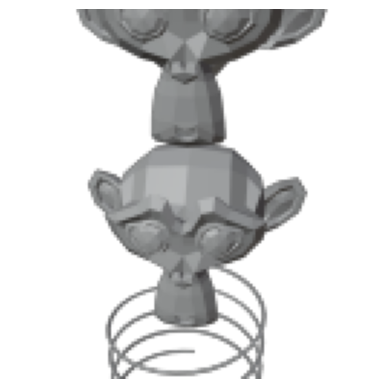

In [16]:
img = read_thumbnail("/mnt/vfx_library/developement_projects/YOUTUBE/blender/blender DNA/structures_uncompressed.blend")
plt.imshow(img)
plt.axis("off")

plt.show()

plt.imsave("camera_thumbnail.png", img)
